| **Evaluation Aspect**        | **Details / Results**                                                                                              |
|-----------------------------|------------------------------------------------------------------------------------------------------------------|
| **Model Configuration**     | Causal Transformer with FastText embeddings, relative position embeddings, 6 layers, 6 attention heads, hidden dim=300, FF dim=1024, vocab size=10,000, max seq length=128 |
| **Training Time**           | 4626.10 seconds (approx. 1 hour 17 mins)                                                                         |
| **Training Set Evaluation** |                                                                                                                  |
| - Accuracy                  | 71.57%                                                                                                           |
| - Confusion Matrix Built?   | Yes                                                                                                              |
| - F1 Score Positive         | 0.7596                                                                                                           |
| - F1 Score Neutral          | 0.6305                                                                                                           |
| - F1 Score Negative         | 0.7436                                                                                                           |
| - AUC Plotted?              | Yes                                                                                                              |
| - AUC Value                 | 0.4982                                                                                                           |
| **Testing Set Evaluation**  |                                                                                                                  |
| - Accuracy                  | 69.86%                                                                                                           |
| - Confusion Matrix Built?   | Yes                                                                                                              |
| - F1 Score Positive         | 0.7365                                                                                                           |
| - F1 Score Neutral          | 0.6166                                                                                                           |
| - F1 Score Negative         | 0.7294                                                                                                           |
| - AUC Plotted?              | Yes                                                                                                              |
| - AUC Value                 | 0.8800 (OvR)                                                                                                     |


In [2]:
!pip install --upgrade scipy

import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gensim.downloader as api
import warnings
warnings.filterwarnings('ignore')

In [11]:
!pip install --upgrade "scipy>=1.10.0"


In [12]:
import scipy
print(scipy.__version__)


1.15.3


In [13]:
import sys, subprocess, importlib, json, textwrap

# 1️⃣  Show where this kernel’s Python lives
print("Current Python executable:", sys.executable)

# 2️⃣  Install a modern SciPy into *this* interpreter
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade", "scipy>=1.12.0,<2.0"
])

# 3️⃣  Verify the version immediately
import scipy
print("SciPy after upgrade (may still say old until you restart):", scipy.__version__)


Current Python executable: /Users/siddhi/miniconda3/envs/myenv/bin/python
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
SciPy after upgrade (may still say old until you restart): 1.15.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.


In [14]:
import sys
!{sys.executable} -m pip uninstall -y scipy


Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3


In [15]:
!{sys.executable} -m pip install scipy==1.11.4


  Using cached scipy-1.11.4-cp310-cp310-macosx_12_0_arm64.whl.metadata (112 kB)
Using cached scipy-1.11.4-cp310-cp310-macosx_12_0_arm64.whl (29.8 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.


In [8]:
!{sys.executable} -m pip install scipy==1.11.4


In [3]:
import scipy
print("✅ Final SciPy version:", scipy.__version__)

import gensim.downloader as api


✅ Final SciPy version: 1.10.1


In [17]:
pip install scipy==1.10.1


  Using cached scipy-1.10.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (53 kB)
Using cached scipy-1.10.1-cp310-cp310-macosx_12_0_arm64.whl (28.8 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.10.1 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install --upgrade gensim


  Using cached gensim-4.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.2 kB)
Using cached gensim-4.3.3-cp310-cp310-macosx_11_0_arm64.whl (24.0 MB)
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.2
    Uninstalling gensim-4.3.2:
      Successfully uninstalled gensim-4.3.2
Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install gensim==4.3.2 scipy==1.10.1


  Using cached gensim-4.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.4 kB)
Using cached gensim-4.3.2-cp310-cp310-macosx_11_0_arm64.whl (24.0 MB)
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.3
    Uninstalling gensim-4.3.3:
      Successfully uninstalled gensim-4.3.3
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Loading dataset and preprocessing files...")

# Load the dataset
df = pd.read_csv('case_study2/Cleaned_Dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns.tolist()}")
print(f"Sample data:\n{df.head()}")

# Load preprocessing files
with open('case_study2/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
    
with open('case_study2/label_encoder_1.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
    
with open('case_study2/class_weights.pkl', 'rb') as f:
    class_weights = pickle.load(f)

print(f"Classes: {label_encoder.classes_}")
print(f"Class distribution:\n{df['Sentiment'].value_counts()}")

Loading dataset and preprocessing files...
Dataset shape: (90000, 6)
Dataset columns: ['Tweet', 'Sentiment', 'Cleaned_Text', 'Sentiment_Merged', 'Tokenized_Tweet', 'Tweet_Vector']
Sample data:
                                               Tweet   Sentiment  \
0  @HOfTheNorth @RichGartonCTV @CTVWindsor Yes, "...  Strong_Pos   
1  NYT editorial board backs Freedom Convoy's rig...    Mild_Pos   
2  Canadian protestors respond to emergency crypt...    Mild_Pos   
3  I would 100% believe that Biden was sitting in...    Mild_Pos   
4  @OfficialNedBTLS At least one of the convoys a...    Mild_Pos   

                                        Cleaned_Text Sentiment_Merged  \
0  yes they mean people who attend the freedom co...         Positive   
1  nyt editorial board back freedom convoy s righ...         Positive   
2  canadian protestor respond to emergency crypto...         Positive   
3  i would 100 believe that biden be sit in some ...         Positive   
4  at least one of the convoy alr

In [5]:
# Load FastText embeddings
print("Loading FastText embeddings...")
try:
    # Try to load pre-downloaded FastText
    fasttext_model = api.load('fasttext-wiki-news-subwords-300')
    embedding_dim = 300
    print("FastText embeddings loaded successfully!")
except:
    print("FastText not available, using random embeddings for demo")
    embedding_dim = 300
    fasttext_model = None

# Prepare data
print("Preparing data...")
texts = df['Cleaned_Text'].tolist()
labels = df['Sentiment_Merged'].tolist()

# Encode labels
encoded_labels = label_encoder.transform(labels)
num_classes = len(label_encoder.classes_)

# Create train/test split ensuring >5000 test samples
X_train, X_test, y_train, y_test = train_test_split(
    texts, encoded_labels, test_size=0.3, random_state=42, stratify=encoded_labels
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Test samples > 5000: {len(X_test) > 5000}")

# Further split training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Final split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Loading FastText embeddings...
FastText embeddings loaded successfully!
Preparing data...
Train samples: 63000
Test samples: 27000
Test samples > 5000: True
Final split - Train: 50400, Val: 12600, Test: 27000


In [6]:
# Tokenization and vocabulary building
def build_vocab(texts, max_vocab_size=10000):
    """Build vocabulary from texts"""
    word_freq = Counter()
    for text in texts:
        if isinstance(text, str):
            words = text.lower().split()
            word_freq.update(words)
    
    # Add special tokens
    vocab = {'<PAD>': 0, '<UNK>': 1, '<START>': 2, '<END>': 3}
    
    # Add most frequent words
    for word, freq in word_freq.most_common(max_vocab_size - len(vocab)):
        vocab[word] = len(vocab)
    
    return vocab

# Build vocabulary
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 10000


In [7]:

# Create embedding matrix from FastText
def create_embedding_matrix(vocab, fasttext_model, embedding_dim):
    """Create embedding matrix from FastText model"""
    embedding_matrix = np.random.normal(0, 0.1, (vocab_size, embedding_dim))
    
    if fasttext_model is not None:
        found_words = 0
        for word, idx in vocab.items():
            if word in fasttext_model:
                embedding_matrix[idx] = fasttext_model[word]
                found_words += 1
        print(f"Found {found_words}/{vocab_size} words in FastText embeddings")
    else:
        print("Using random embeddings")
    
    return embedding_matrix

embedding_matrix = create_embedding_matrix(vocab, fasttext_model, embedding_dim)

Found 8324/10000 words in FastText embeddings


In [8]:
# Text preprocessing function
def text_to_sequence(text, vocab, max_length=128):
    """Convert text to sequence of token IDs"""
    if not isinstance(text, str):
        return [vocab['<PAD>']] * max_length
    
    words = text.lower().split()
    sequence = [vocab.get(word, vocab['<UNK>']) for word in words]
    
    # Pad or truncate
    if len(sequence) < max_length:
        sequence += [vocab['<PAD>']] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]
    
    return sequence

In [9]:
# Convert texts to sequences
max_length = 128
X_train_seq = [text_to_sequence(text, vocab, max_length) for text in X_train]
X_val_seq = [text_to_sequence(text, vocab, max_length) for text in X_val]
X_test_seq = [text_to_sequence(text, vocab, max_length) for text in X_test]

# Convert to tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Data preprocessing completed!")

Data preprocessing completed!


In [10]:

# Dataset class
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Create datasets
train_dataset = SentimentDataset(X_train_tensor, y_train_tensor)
val_dataset = SentimentDataset(X_val_tensor, y_val_tensor)
test_dataset = SentimentDataset(X_test_tensor, y_test_tensor)

In [11]:
class RelativePositionEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.max_len = max_len
        self.d_model = d_model
        
        # Create relative position embeddings
        self.rel_pos_emb = nn.Embedding(2 * max_len - 1, d_model)
        
    def forward(self, seq_len):
        device = self.rel_pos_emb.weight.device  # get correct device

        positions = torch.arange(seq_len, device=device).unsqueeze(0) - torch.arange(seq_len, device=device).unsqueeze(1)
        positions = positions + self.max_len - 1  # Shift to positive indices
        positions = torch.clamp(positions, 0, 2 * self.max_len - 2)

        return self.rel_pos_emb(positions)


In [12]:
# Causal Multi-Head Attention with Relative Positions
class CausalMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, max_len):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        
        self.rel_pos_encoding = RelativePositionEncoding(max_len, self.head_dim)
        
        # Create causal mask
        self.register_buffer('causal_mask', torch.tril(torch.ones(max_len, max_len)))
        

    def forward(self, x):
        batch_size, seq_len, d_model = x.size()

        # Linear projections
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, L, D]
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention (absolute positions)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)  # [B, H, L, L]

        # Relative position embeddings
        rel_pos = self.rel_pos_encoding(seq_len)  # [L, L, D]
        rel_pos = rel_pos.unsqueeze(0).unsqueeze(0)  # [1, 1, L, L, D]
        Q_exp = Q.unsqueeze(3)  # [B, H, L, 1, D]
        rel_scores = torch.sum(Q_exp * rel_pos, dim=-1) / np.sqrt(self.head_dim)  # [B, H, L, L]

        # Add to attention scores
        scores = scores + rel_scores

        # Causal mask
        mask = self.causal_mask[:seq_len, :seq_len].unsqueeze(0).unsqueeze(0).to(x.device)  # [1, 1, L, L]
        scores = scores.masked_fill(mask == 0, float('-inf'))

        # Attention weights
        attention_weights = F.softmax(scores, dim=-1)

        # Context vectors
        context = torch.matmul(attention_weights, V)  # [B, H, L, D]
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        return self.out_linear(context), attention_weights



In [13]:
# Feed Forward Network
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.attention = CausalMultiHeadAttention(d_model, num_heads, max_len)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # Self-attention with residual connection
        attn_output, attention_weights = self.attention(x)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed forward with residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x, attention_weights



In [14]:
class CausalTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, 
                 max_len, num_classes, embedding_matrix=None, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, d_model)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
            self.embedding.weight.requires_grad = False  # Freeze pretrained embeddings

        # Positional embeddings
        self.pos_embedding = nn.Embedding(max_len, d_model)

        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, max_len, dropout)
            for _ in range(num_layers)
        ])

        # Dropout + Classification head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

        self.init_weights()

    def init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding) and module != self.embedding:
                nn.init.xavier_uniform_(module.weight)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        batch_size, seq_len = x.size()

        # Token + position embeddings
        token_emb = self.embedding(x)  # [batch_size, seq_len, d_model]
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        pos_emb = self.pos_embedding(positions)

        x = self.dropout(token_emb + pos_emb)

        # Transformer blocks
        attention_weights = []
        for transformer_block in self.transformer_blocks:
            x, attn_weights = transformer_block(x)
            attention_weights.append(attn_weights)

        # Global average pooling
        x = torch.mean(x, dim=1)  # [batch_size, d_model]

        # Final classification
        logits = self.classifier(x)

        return logits, attention_weights


In [15]:
config = {
    'vocab_size': vocab_size,
    'd_model': embedding_dim,  # 300
    'num_heads': 6,            # ✅ instead of 8
    'num_layers': 6,
    'd_ff': 1024,
    'max_len': max_length,
    'num_classes': num_classes,
    'dropout': 0.1
}
print("Model Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Model Configuration:
  vocab_size: 10000
  d_model: 300
  num_heads: 6
  num_layers: 6
  d_ff: 1024
  max_len: 128
  num_classes: 3
  dropout: 0.1


In [16]:
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = CausalTransformer(
    vocab_size=config['vocab_size'],
    d_model=config['d_model'],
    num_heads=config['num_heads'],
    num_layers=config['num_layers'],
    d_ff=config['d_ff'],
    max_len=config['max_len'],
    num_classes=config['num_classes'],
    embedding_matrix=embedding_matrix,
    dropout=config['dropout']
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cpu
Total parameters: 8,984,547
Trainable parameters: 5,984,547


In [17]:
# Training setup
batch_size = 32
learning_rate = 1e-4
num_epochs = 10

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [18]:
# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        output, _ = model(data)
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
        
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}')
    
    return total_loss / len(dataloader), 100. * correct / total

In [19]:
# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            
            output, _ = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    return total_loss / len(dataloader), 100. * correct / total, all_predictions, all_targets


In [20]:
# Training loop
print("Starting training...")
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

import time
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    # Learning rate scheduling
    scheduler.step()
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Early stopping check
    if epoch > 0 and val_loss > min(val_losses[:-1]):
        print("Early stopping criterion met")
        break

end_time = time.time()
train_time = end_time - start_time
print(f"\nTraining completed in {train_time:.2f} seconds")

Starting training...

Epoch 1/10
--------------------------------------------------
Batch 0/1575, Loss: 1.1493
Batch 100/1575, Loss: 1.0377
Batch 200/1575, Loss: 0.7768
Batch 300/1575, Loss: 0.7200
Batch 400/1575, Loss: 0.9100
Batch 500/1575, Loss: 0.6906
Batch 600/1575, Loss: 0.8082
Batch 700/1575, Loss: 0.9011
Batch 800/1575, Loss: 0.8501
Batch 900/1575, Loss: 0.7623
Batch 1000/1575, Loss: 0.7790
Batch 1100/1575, Loss: 1.0053
Batch 1200/1575, Loss: 0.6976
Batch 1300/1575, Loss: 0.6028
Batch 1400/1575, Loss: 0.7012
Batch 1500/1575, Loss: 0.7271
Train Loss: 0.8340, Train Acc: 62.12%
Val Loss: 0.8169, Val Acc: 66.16%

Epoch 2/10
--------------------------------------------------
Batch 0/1575, Loss: 0.9416
Batch 100/1575, Loss: 0.8454
Batch 200/1575, Loss: 0.6965
Batch 300/1575, Loss: 0.7558
Batch 400/1575, Loss: 0.6452
Batch 500/1575, Loss: 0.9690
Batch 600/1575, Loss: 0.6892
Batch 700/1575, Loss: 0.8557
Batch 800/1575, Loss: 0.7852
Batch 900/1575, Loss: 0.5648
Batch 1000/1575, Loss: 0.

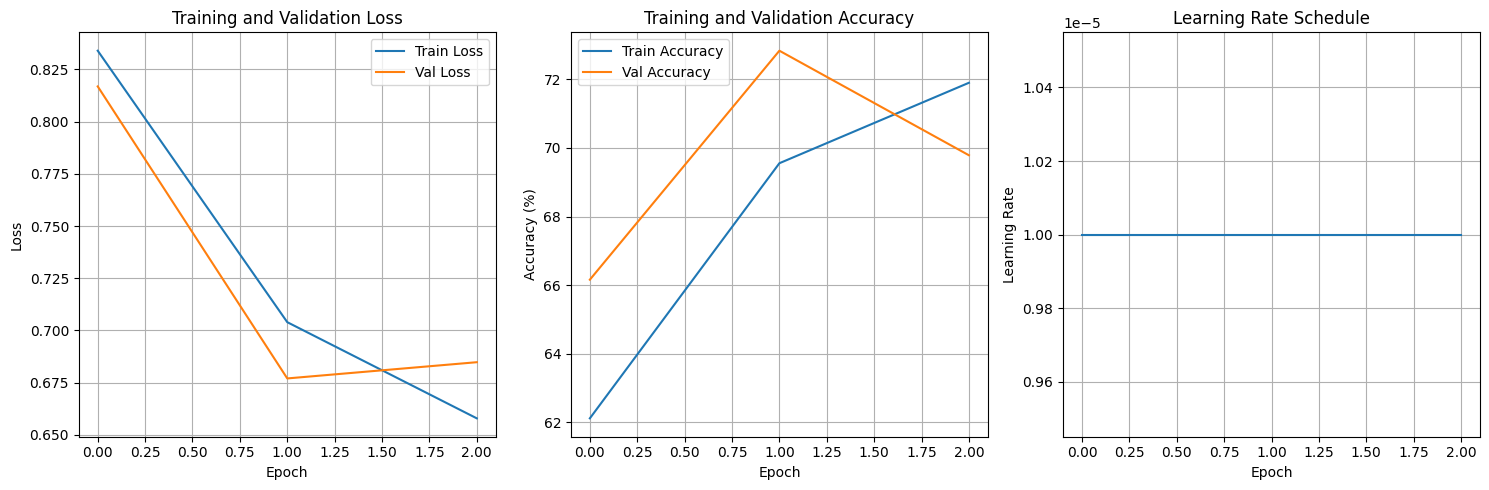

In [21]:
# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot([opt.param_groups[0]['lr'] for opt in [optimizer] * len(train_losses)])
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# Test evaluation
print("\nEvaluating on test set...")
test_loss, test_acc, test_predictions, test_targets = validate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Get probabilities for AUC calculation
model.eval()
all_probabilities = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        output, _ = model(data)
        probabilities = F.softmax(output, dim=1)
        all_probabilities.append(probabilities.cpu().numpy())

all_probabilities = np.vstack(all_probabilities)


Evaluating on test set...
Test Loss: 0.6818
Test Accuracy: 69.86%



DETAILED EVALUATION METRICS
Test Accuracy: 0.6986 (69.86%)

Classification Report:
              precision    recall  f1-score   support

    Negative     0.6049    0.9184    0.7294      9000
     Neutral     0.7213    0.5384    0.6166      9000
    Positive     0.8690    0.6390    0.7365      9000

    accuracy                         0.6986     27000
   macro avg     0.7318    0.6986    0.6942     27000
weighted avg     0.7318    0.6986    0.6942     27000

F1 Score for Negative: 0.7294
F1 Score for Neutral: 0.6166
F1 Score for Positive: 0.7365

Confusion Matrix:
[[8266  492  242]
 [3529 4846  625]
 [1869 1380 5751]]


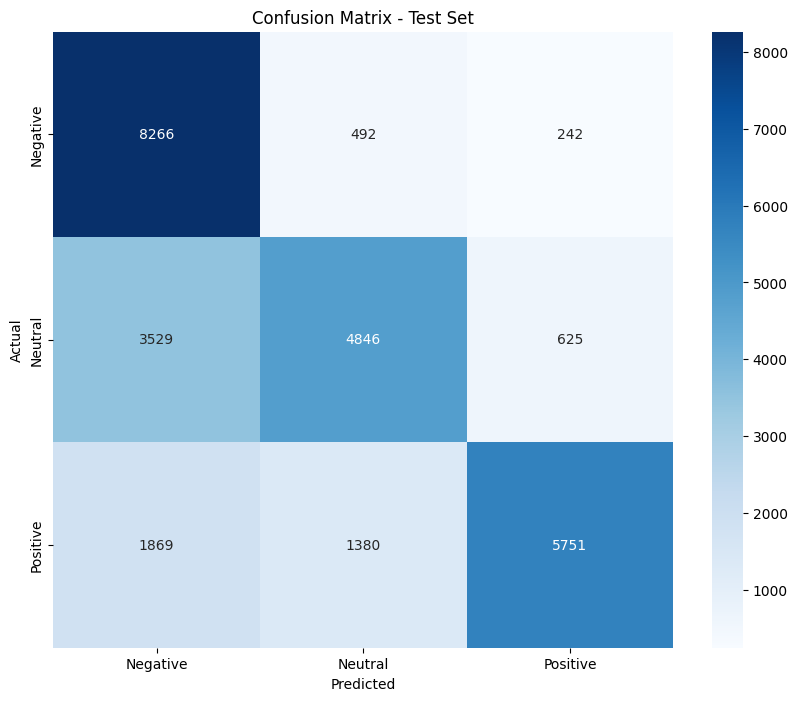

In [23]:
# Calculate metrics
print("\n" + "="*50)
print("DETAILED EVALUATION METRICS")
print("="*50)

# Accuracy
accuracy = accuracy_score(test_targets, test_predictions)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_targets, test_predictions, 
                          target_names=label_encoder.classes_, digits=4))

# F1 Scores
f1_scores = {}
for i, class_name in enumerate(label_encoder.classes_):
    f1 = f1_score(test_targets, test_predictions, labels=[i], average='macro')
    f1_scores[class_name] = f1
    print(f"F1 Score for {class_name}: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(test_targets, test_predictions)
print(f"\nConfusion Matrix:\n{cm}")

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

AUC Score (OvR): 0.8800


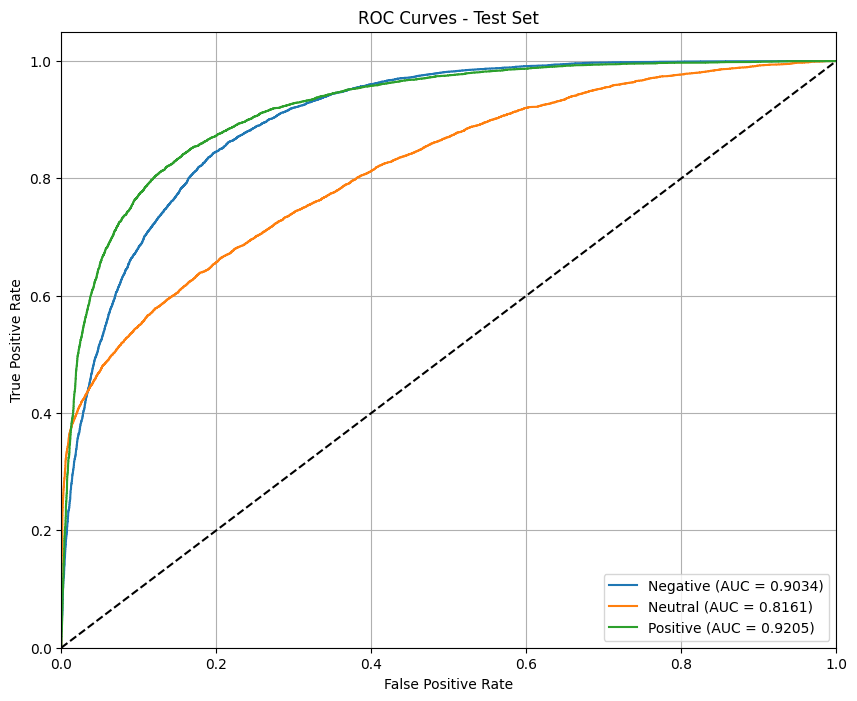

In [24]:
# ROC AUC Score
if num_classes == 2:
    auc_score = roc_auc_score(test_targets, all_probabilities[:, 1])
    print(f"AUC Score: {auc_score:.4f}")
else:
    auc_score = roc_auc_score(test_targets, all_probabilities, multi_class='ovr')
    print(f"AUC Score (OvR): {auc_score:.4f}")

# Plot ROC Curves
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

if num_classes == 2:
    fpr, tpr, _ = roc_curve(test_targets, all_probabilities[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
else:
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve((np.array(test_targets) == i).astype(int), 
                               all_probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Per-class metrics
print("\nPer-Class Metrics:")
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = np.array(test_targets) == i
    class_predictions = np.array(test_predictions)[class_mask]
    class_accuracy = np.mean(class_predictions == i)
    
    precision = np.sum((np.array(test_predictions) == i) & (np.array(test_targets) == i)) / np.sum(np.array(test_predictions) == i)
    recall = np.sum((np.array(test_predictions) == i) & (np.array(test_targets) == i)) / np.sum(np.array(test_targets) == i)
    
    print(f"{class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1_scores[class_name]:.4f}")

# Model summary
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Model Type: Causal Transformer with FastText Embeddings")
print(f"Embedding Type: FastText (pretrained)")
print(f"Position Encoding: Relative Position Embeddings")
print(f"Attention Type: Causal (Masked) Multi-Head Attention")
print(f"Number of Attention Heads: {config['num_heads']}")
print(f"Number of Layers: {config['num_layers']}")
print(f"Hidden Dimension: {config['d_model']}")
print(f"Feed Forward Dimension: {config['d_ff']}")
print(f"Vocabulary Size: {config['vocab_size']}")
print(f"Maximum Sequence Length: {config['max_len']}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Training Time: {train_time:.2f} seconds")
print(f"Device Used: {device}")

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'vocab': vocab,
    'label_encoder': label_encoder,
    'test_accuracy': accuracy,
    'test_auc': auc_score,
    'f1_scores': f1_scores
}, 'causal_transformer_fasttext.pth')

print("\nModel saved successfully!")
print("Training and evaluation completed!")


Per-Class Metrics:
Negative:
  Precision: 0.6049
  Recall: 0.9184
  F1-Score: 0.7294
Neutral:
  Precision: 0.7213
  Recall: 0.5384
  F1-Score: 0.6166
Positive:
  Precision: 0.8690
  Recall: 0.6390
  F1-Score: 0.7365

MODEL SUMMARY
Model Type: Causal Transformer with FastText Embeddings
Embedding Type: FastText (pretrained)
Position Encoding: Relative Position Embeddings
Attention Type: Causal (Masked) Multi-Head Attention
Number of Attention Heads: 6
Number of Layers: 6
Hidden Dimension: 300
Feed Forward Dimension: 1024
Vocabulary Size: 10000
Maximum Sequence Length: 128
Total Parameters: 8,984,547
Trainable Parameters: 5,984,547
Training Time: 4626.10 seconds
Device Used: cpu

Model saved successfully!
Training and evaluation completed!


In [26]:
print(" TEST DATA CHECK")


# Basic info
print(f"Number of Test Samples: {len(X_test)}")
print(f"Sequence Length (after padding): {len(X_test_tensor[0])}")
print(f"Label Classes: {label_encoder.classes_.tolist()}")
print(f"Test Label Distribution:")

# Distribution of labels
label_counts = pd.Series(y_test).value_counts()
for i, count in label_counts.items():
    label_name = label_encoder.inverse_transform([i])[0]
    print(f"  {label_name}: {count} samples")

# Sample visualization
print("\n Sample Test Text & Label")
for i in range(3):
    print(f"\nSample #{i+1}")
    print("Text:", X_test[i])
    print("True Label:", label_encoder.inverse_transform([y_test[i]])[0])
    print("Token IDs:", X_test_seq[i][:10], "...")  # show first 10 tokens



 TEST DATA CHECK
Number of Test Samples: 27000
Sequence Length (after padding): 128
Label Classes: ['Negative', 'Neutral', 'Positive']
Test Label Distribution:
  Positive: 9000 samples
  Neutral: 9000 samples
  Negative: 9000 samples

 Sample Test Text & Label

Sample #1
Text: freedom convoy ottawa dec 29 2022
True Label: Positive
Token IDs: [7, 8, 23, 4887, 1878, 74, 0, 0, 0, 0] ...

Sample #2
Text: freedomconvoy get catch up with the convoy evening feb 6 22
True Label: Neutral
Token IDs: [13, 60, 948, 67, 25, 4, 8, 2814, 288, 413] ...

Sample #3
Text: let s do this freedom freedomconvoy freedomconvoycanada freedomfighter
True Label: Neutral
Token IDs: [216, 26, 30, 22, 7, 13, 347, 2062, 0, 0] ...


In [27]:
print(f"\nTraining completed in {train_time:.2f} seconds")



Training completed in 4626.10 seconds


TRAINING SET EVALUATION METRICS
Training Accuracy: 71.57%

Classification Report (Train):
              precision    recall  f1-score   support

    Negative     0.6150    0.9402    0.7436     16800
     Neutral     0.7487    0.5445    0.6305     16800
    Positive     0.8904    0.6623    0.7596     16800

    accuracy                         0.7157     50400
   macro avg     0.7513    0.7157    0.7112     50400
weighted avg     0.7513    0.7157    0.7112     50400


F1 Scores (Train):
  Negative: 0.7436
  Neutral: 0.6305
  Positive: 0.7596

AUC Score (Train):
AUC Score (Train): 0.4982

Confusion Matrix (Train):


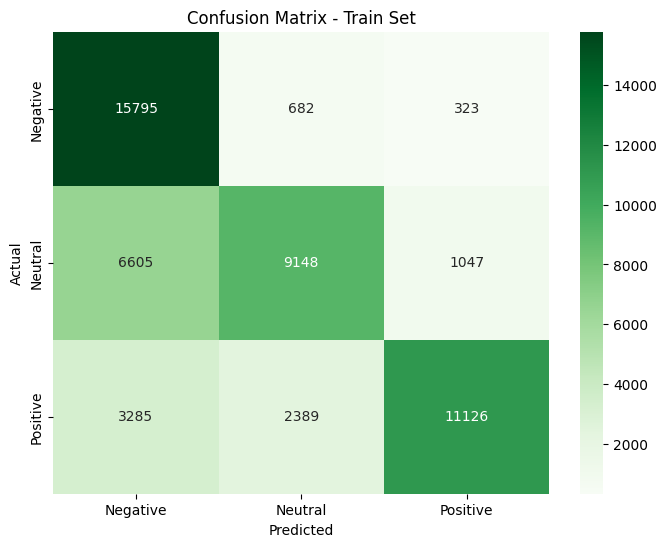

In [28]:
# ===========================
# TRAINING SET EVALUATION
# ===========================

print("TRAINING SET EVALUATION METRICS")


train_loss_eval, train_acc_eval, train_predictions, train_targets = validate(
    model, train_loader, criterion, device
)

# Accuracy
print(f"Training Accuracy: {train_acc_eval:.2f}%")

# Classification Report
print("\nClassification Report (Train):")
print(classification_report(train_targets, train_predictions, 
                            target_names=label_encoder.classes_, digits=4))

# F1 Scores for each class
print("\nF1 Scores (Train):")
for i, class_name in enumerate(label_encoder.classes_):
    f1 = f1_score(train_targets, train_predictions, labels=[i], average='macro')
    print(f"  {class_name}: {f1:.4f}")

# AUC Score
print("\nAUC Score (Train):")
model.eval()
train_probs = []
with torch.no_grad():
    for data, _ in train_loader:
        data = data.to(device)
        output, _ = model(data)
        prob = F.softmax(output, dim=1)
        train_probs.append(prob.cpu().numpy())

train_probs = np.vstack(train_probs)

if num_classes == 2:
    auc_train = roc_auc_score(train_targets, train_probs[:, 1])
else:
    auc_train = roc_auc_score(train_targets, train_probs, multi_class='ovr')

print(f"AUC Score (Train): {auc_train:.4f}")

# Optional: Confusion Matrix for Train Set
print("\nConfusion Matrix (Train):")
cm_train = confusion_matrix(train_targets, train_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Train Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


| **Next Steps**                     |                                                 |
|----------------------------------|-------------------------------------------------|
| 1) Hyperparameter tuning: experiment with learning rate, number of layers, attention heads, batch size to improve accuracy and F1 scores. |
| 2) Experiment with different pretrained embeddings such as ELMo or contextual embeddings to compare performance against FastText. |
| 3) Implement advanced regularization techniques like dropout, weight decay, or layer normalization to reduce overfitting. |
| 4) Explore data augmentation or class balancing strategies to improve model robustness, especially on Neutral class. |
| 5) Evaluate model on external or real-world datasets to check generalizability and domain adaptation. |


In [33]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset

def train_and_evaluate_cv(texts, labels, vocab, embedding_matrix, label_encoder, config, num_folds=5):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    fold_accuracies = []
    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels)):
        print(f"\n--- Fold {fold+1} ---")

        # Prepare train/val splits
        X_train_fold = [texts[i] for i in train_idx]
        y_train_fold = labels[train_idx]
        X_val_fold = [texts[i] for i in val_idx]
        y_val_fold = labels[val_idx]

        # Convert texts to sequences
        max_length = config['max_len']
        X_train_seq = [text_to_sequence(t, vocab, max_length) for t in X_train_fold]
        X_val_seq = [text_to_sequence(t, vocab, max_length) for t in X_val_fold]

        # Convert to tensors
        X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.long)
        X_val_tensor = torch.tensor(X_val_seq, dtype=torch.long)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.long)

        # Datasets and loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # Initialize model
        model = CausalTransformer(
            vocab_size=config['vocab_size'],
            d_model=config['d_model'],
            num_heads=config['num_heads'],
            num_layers=config['num_layers'],
            d_ff=config['d_ff'],
            max_len=config['max_len'],
            num_classes=config['num_classes'],
            embedding_matrix=embedding_matrix,
            dropout=config['dropout']
        ).to(device)

        criterion = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

        # Train for fewer epochs for CV speed, e.g., 5 epochs
        epochs = 5
        for epoch in range(epochs):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_preds, val_targets = validate(model, val_loader, criterion, device)
            scheduler.step()

            print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        # Compute F1 score for validation fold
        f1 = f1_score(val_targets, val_preds, average='macro')
        print(f"Fold {fold+1} Validation F1 Score: {f1:.4f}")

        fold_accuracies.append(val_acc)
        fold_f1s.append(f1)

    print(f"\nAverage CV Accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Average CV F1 Score: {np.mean(fold_f1s):.4f}")

    return fold_accuracies, fold_f1s


In [34]:
texts = df['Cleaned_Text'].tolist()
labels = label_encoder.transform(df['Sentiment_Merged'])

fold_accuracies, fold_f1s = train_and_evaluate_cv(
    texts, labels, vocab, embedding_matrix, label_encoder, config, num_folds=5
)



--- Fold 1 ---
Batch 0/2250, Loss: 1.2529
Batch 100/2250, Loss: 1.0010
Batch 200/2250, Loss: 0.9453
Batch 300/2250, Loss: 0.9495
Batch 400/2250, Loss: 1.0942
Batch 500/2250, Loss: 0.6699
Batch 600/2250, Loss: 0.8205
Batch 700/2250, Loss: 0.8844
Batch 800/2250, Loss: 0.7887
Batch 900/2250, Loss: 0.8924
Batch 1000/2250, Loss: 0.7065
Batch 1100/2250, Loss: 0.6609
Batch 1200/2250, Loss: 0.8169
Batch 1300/2250, Loss: 0.8027
Batch 1400/2250, Loss: 0.5881
Batch 1500/2250, Loss: 0.5674
Batch 1600/2250, Loss: 0.6284
Batch 1700/2250, Loss: 0.7308
Batch 1800/2250, Loss: 0.7808
Batch 1900/2250, Loss: 0.6400
Batch 2000/2250, Loss: 0.9645
Batch 2100/2250, Loss: 0.9803
Batch 2200/2250, Loss: 0.5801
Epoch 1: Train Acc: 64.17%, Val Acc: 70.11%
Batch 0/2250, Loss: 0.4761
Batch 100/2250, Loss: 0.6871
Batch 200/2250, Loss: 0.6653
Batch 300/2250, Loss: 0.5806
Batch 400/2250, Loss: 0.6867
Batch 500/2250, Loss: 0.6907
Batch 600/2250, Loss: 0.7977
Batch 700/2250, Loss: 0.5850
Batch 800/2250, Loss: 0.5547
Bat

KeyboardInterrupt: 